# Customer Churn Prediction — Step 9: Final Model Inference and Prediction

**Input:** `models/final_churn_model.joblib` — the complete trained `Pipeline` saved in Step 8  

### What this notebook does
Demonstrates how to load the saved final model and run it against new, unseen customer records to generate churn predictions and probability scores.

### What this notebook does NOT do
- Does **not** retrain the model.
- Does **not** modify the raw dataset.
- Does **not** fit any preprocessing transformation — the saved pipeline handles all of that internally.
- Does **not** create a web application or API.

---

## 1. Setup — Imports and Paths

In [19]:
import os
import copy
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12,
                     'axes.labelsize': 11, 'xtick.labelsize': 10})

RANDOM_STATE = 42

NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == 'notebook' else NOTEBOOK_DIR
FINAL_PATH   = os.path.join(PROJECT_ROOT, 'models', 'final_churn_model.joblib')
SPLITS_PATH  = os.path.join(PROJECT_ROOT, 'data', 'preprocessed_splits.pkl')
MODELS_PATH  = os.path.join(PROJECT_ROOT, 'data', 'trained_models.pkl')
CLEAN_PATH   = os.path.join(PROJECT_ROOT, 'data', 'telco_churn_cleaned.csv')
RAW_PATH     = os.path.join(PROJECT_ROOT, 'data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Final model path:', FINAL_PATH)
print('File exists     :', os.path.exists(FINAL_PATH))

Final model path: c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\models\final_churn_model.joblib
File exists     : True


---
## 2. Load the Final Model Pipeline

We load `models/final_churn_model.joblib` — the complete, self-contained scikit-learn `Pipeline` saved in Step 8.  
This single file contains:
- The **fitted `ColumnTransformer`** (knows every scaler mean/std and every encoder category vocabulary from training).
- The **fitted `RandomForestClassifier`** (200 trees, all learned splits).

No separate preprocessing step is needed on new data. Calling `pipeline.predict(new_X)` handles everything.

If the joblib file is not present (Step 8 has not been executed in this environment), the cell below automatically rebuilds and saves the exact same pipeline — using the identical parameters from Step 6 — so this notebook is always runnable.

In [20]:
def _rebuild_and_save_final_model():
    """Rebuild the Random Forest pipeline from Step 6 and save to models/."""
    print('  Building preprocessing pipeline ...')
    numerical_features   = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

    # Load or reconstruct the training split
    if os.path.exists(SPLITS_PATH):
        splits = joblib.load(SPLITS_PATH)
        X_train = splits['X_train']
        y_train = splits['y_train']
        categorical_features = splits['categorical_features']
    else:
        df = pd.read_csv(CLEAN_PATH)
        X  = df.drop(columns=['Churn'])
        y  = (df['Churn'] == 'Yes').astype(int)
        categorical_features = [c for c in X.columns if c not in numerical_features]
        X_train, _, y_train, _ = train_test_split(
            X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                         ('scaler',  StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('encoder', OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))])
    preprocessor = ColumnTransformer(
        transformers=[('num', num_pipe, numerical_features),
                      ('cat', cat_pipe, categorical_features)],
        remainder='drop'
    )
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200, min_samples_leaf=5,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
    print('  Training Random Forest pipeline on X_train ...')
    pipeline.fit(X_train, y_train)
    os.makedirs(os.path.dirname(FINAL_PATH), exist_ok=True)
    joblib.dump(pipeline, FINAL_PATH)
    print(f'  Saved to: {FINAL_PATH}')
    return pipeline


if os.path.exists(FINAL_PATH):
    print('Loading final model from:', FINAL_PATH)
    final_model = joblib.load(FINAL_PATH)
    print('Model loaded successfully.')
else:
    print('models/final_churn_model.joblib not found.')
    print('Rebuilding from scratch (run Step 8 to generate it directly) ...')
    final_model = _rebuild_and_save_final_model()

print()
print('Type:', type(final_model))
print('Steps:', [(name, type(obj).__name__) for name, obj in final_model.steps])

Loading final model from: c:\Users\Subham\OneDrive\Documents\Desktop\Customer_Churn_Project\models\final_churn_model.joblib
Model loaded successfully.

Type: <class 'sklearn.pipeline.Pipeline'>
Steps: [('preprocessor', 'ColumnTransformer'), ('classifier', 'RandomForestClassifier')]


---
## 3. Verify the Loaded Pipeline

Before running inference we confirm that:  
1. The loaded object is a scikit-learn `Pipeline`.  
2. Both the `ColumnTransformer` and the `RandomForestClassifier` are already fitted.  
3. The pipeline expects exactly 19 input feature columns — the same as the training data.  
4. `predict_proba` is available (required for probability scores).

In [21]:
preprocessor_step = final_model.named_steps['preprocessor']
classifier_step   = final_model.named_steps['classifier']

# Gather expected feature names from the ColumnTransformer's input
expected_features = (
    preprocessor_step.transformers[0][2]   # numerical feature names
    + preprocessor_step.transformers[1][2] # categorical feature names
)

checks = {
    'Is a scikit-learn Pipeline'         : isinstance(final_model, Pipeline),
    'ColumnTransformer is fitted'        : hasattr(preprocessor_step, 'transformers_'),
    'RandomForestClassifier is fitted'   : hasattr(classifier_step, 'n_features_in_'),
    'predict_proba available'            : hasattr(final_model, 'predict_proba'),
    'Number of expected input features'  : len(expected_features),
    'Number of output classes'           : len(classifier_step.classes_),
}

print('=== Pipeline Verification ===')
for label, value in checks.items():
    status = '' if isinstance(value, int) else ('OK' if value else 'FAIL')
    print(f'  {label:<44} {value}  {status}')

print()
print('Expected input columns (19):')
for i, feat in enumerate(expected_features, 1):
    print(f'  {i:>2}. {feat}')

=== Pipeline Verification ===
  Is a scikit-learn Pipeline                   True  
  ColumnTransformer is fitted                  True  
  RandomForestClassifier is fitted             True  
  predict_proba available                      True  
  Number of expected input features            19  
  Number of output classes                     2  

Expected input columns (19):
   1. SeniorCitizen
   2. tenure
   3. MonthlyCharges
   4. TotalCharges
   5. gender
   6. Partner
   7. Dependents
   8. PhoneService
   9. MultipleLines
  10. InternetService
  11. OnlineSecurity
  12. OnlineBackup
  13. DeviceProtection
  14. TechSupport
  15. StreamingTV
  16. StreamingMovies
  17. Contract
  18. PaperlessBilling
  19. PaymentMethod


---
## 4. Create Example New Customer Records

We construct a small DataFrame of **hypothetical new customers** to demonstrate inference.  
These are entirely synthetic records — they are not rows from the original dataset.

The three profiles are designed to span a range of predicted risk levels, based on the patterns identified in the EDA (Step 4) and the feature importance analysis (Step 8):

| Customer | Profile description | Expected risk signal |
|---|---|---|
| C001 | Long-tenured, two-year contract, DSL, online security, automatic payment | **Lower risk** |
| C002 | New customer, month-to-month, fibre optic, no security add-ons, electronic check | **Higher risk** |
| C003 | Mid-tenure, one-year contract, DSL, partial add-ons, mailed check | **Intermediate risk** |
| C004 | Senior customer, month-to-month, fibre optic, paperless billing, high charges | **Higher risk** |
| C005 | Long-tenured, two-year contract, no internet service, no phone service | **Lower risk** |

> **Important:** These profiles were constructed based on EDA-derived associations, but the model's actual predicted probabilities may differ from intuitive expectations — particularly for cases where multiple feature signals partially offset each other.  
> The model's output reflects patterns learned from the training data, not a rule-based system.

In [22]:
new_customers = pd.DataFrame({
    # ──────────────────────────────────── C001: long-tenured, low-risk profile
    # Two-year contract, DSL, all security add-ons, automatic payment, 58 months
    'gender':           ['Female', 'Male',          'Female',       'Male',          'Female'],
    'SeniorCitizen':    [0,        0,               0,              1,               0],
    'Partner':          ['Yes',    'No',            'Yes',          'No',            'Yes'],
    'Dependents':       ['Yes',    'No',            'No',           'No',            'No'],
    'tenure':           [58,       2,               24,             6,               65],
    'PhoneService':     ['Yes',    'Yes',           'Yes',          'Yes',           'No'],
    'MultipleLines':    ['No',     'No',            'Yes',          'Yes',           'No phone service'],
    'InternetService':  ['DSL',    'Fiber optic',   'DSL',          'Fiber optic',   'No'],
    'OnlineSecurity':   ['Yes',    'No',            'Yes',          'No',            'No internet service'],
    'OnlineBackup':     ['Yes',    'No',            'No',           'No',            'No internet service'],
    'DeviceProtection': ['Yes',    'No',            'Yes',          'No',            'No internet service'],
    'TechSupport':      ['Yes',    'No',            'No',           'No',            'No internet service'],
    'StreamingTV':      ['No',     'Yes',           'No',           'Yes',           'No internet service'],
    'StreamingMovies':  ['No',     'Yes',           'Yes',          'Yes',           'No internet service'],
    'Contract':         ['Two year', 'Month-to-month', 'One year',  'Month-to-month', 'Two year'],
    'PaperlessBilling': ['No',     'Yes',           'No',           'Yes',           'No'],
    'PaymentMethod':    ['Bank transfer (automatic)', 'Electronic check',
                         'Mailed check', 'Electronic check',
                         'Credit card (automatic)'],
    'MonthlyCharges':   [55.90,    89.10,           59.65,          99.45,           20.05],
    'TotalCharges':     [3242.20,  178.20,          1431.60,        596.70,          1303.25],
})

customer_ids   = ['C001', 'C002', 'C003', 'C004', 'C005']
risk_profiles  = ['Lower risk', 'Higher risk', 'Intermediate', 'Higher risk', 'Lower risk']
new_customers.index = customer_ids
new_customers.index.name = 'CustomerID'

print(f'New customer records: {new_customers.shape[0]} rows × {new_customers.shape[1]} features')
print()
display(new_customers.T)   # transposed for readability

New customer records: 5 rows × 19 features



CustomerID,C001,C002,C003,C004,C005
gender,Female,Male,Female,Male,Female
SeniorCitizen,0,0,0,1,0
Partner,Yes,No,Yes,No,Yes
Dependents,Yes,No,No,No,No
tenure,58,2,24,6,65
PhoneService,Yes,Yes,Yes,Yes,No
MultipleLines,No,No,Yes,Yes,No phone service
InternetService,DSL,Fiber optic,DSL,Fiber optic,No
OnlineSecurity,Yes,No,Yes,No,No internet service
OnlineBackup,Yes,No,No,No,No internet service


---
## 5. Verify Input Column Alignment

Before calling `predict`, we verify that the `new_customers` DataFrame contains exactly the 19 feature columns the pipeline expects — with the correct names and no extras.  
The `ColumnTransformer` inside the pipeline will use `remainder='drop'` for any unexpected columns, but an explicit check prevents silent errors.

In [23]:
expected = set(expected_features)
provided = set(new_customers.columns)

missing_cols  = expected - provided
extra_cols    = provided - expected

print('=== Input Column Verification ===')
print(f'  Expected columns : {len(expected)}')
print(f'  Provided columns : {len(provided)}')
print(f'  Missing from input   : {missing_cols  if missing_cols  else "None"}')
print(f'  Extra (will be dropped): {extra_cols if extra_cols else "None"}')
print()

if missing_cols:
    raise ValueError(f'New customer DataFrame is missing columns: {missing_cols}')
else:
    print('Column check PASSED — all expected features are present.')

=== Input Column Verification ===
  Expected columns : 19
  Provided columns : 19
  Missing from input   : None
  Extra (will be dropped): None

Column check PASSED — all expected features are present.


---
## 6. Run Inference — Predictions and Probabilities

We call the two inference methods on the `new_customers` DataFrame:  

- **`final_model.predict(new_customers)`** — returns hard class labels (0 = No Churn, 1 = Churn) using the default 0.5 probability threshold.  
- **`final_model.predict_proba(new_customers)[:, 1]`** — returns the model's estimated probability that each customer belongs to the positive class (Churn = 1).  

Internally, the pipeline:  
1. Applies the fitted `ColumnTransformer` to scale the numerical columns and one-hot encode the categorical columns.  
2. Passes the 45-column transformed array to the fitted `RandomForestClassifier`.  
3. Aggregates votes (for `predict`) or probability estimates (for `predict_proba`) across the 200 trees.

In [24]:
predictions   = final_model.predict(new_customers)
probabilities = final_model.predict_proba(new_customers)[:, 1]

print('=== Raw Inference Output ===')
print(f'  Hard predictions  : {predictions}')
print(f'  Churn probabilities: {np.round(probabilities, 4)}')

=== Raw Inference Output ===
  Hard predictions  : [0 1 0 1 0]
  Churn probabilities: [0.1058 0.8853 0.1095 0.9389 0.014 ]


---
## 7. Build and Display the Results DataFrame

We assemble the results into a clean, human-readable table and add a **risk tier** label based on the predicted churn probability.

**Risk tier thresholds:**

| Predicted probability | Risk tier |
|---|---|
| < 0.30 | Lower predicted churn probability |
| 0.30 – 0.60 | Intermediate predicted churn probability |
| > 0.60 | Higher predicted churn probability |

> **These thresholds are illustrative only.** They are chosen to divide the 0–1 probability range into three readable bands for this demonstration. They are **not** calibrated, validated, or intended as operational decision thresholds. In a real deployment, thresholds should be selected based on a cost-benefit analysis of False Positives vs False Negatives specific to the business context.

In [25]:
def risk_tier(prob):
    if prob < 0.30:
        return 'Lower predicted churn probability'
    elif prob <= 0.60:
        return 'Intermediate predicted churn probability'
    else:
        return 'Higher predicted churn probability'


results = pd.DataFrame({
    'CustomerID':          customer_ids,
    'Constructed Profile': risk_profiles,
    'Predicted Class':     ['Churn' if p == 1 else 'No Churn' for p in predictions],
    'Churn Probability':   np.round(probabilities, 4),
    'Risk Tier':           [risk_tier(p) for p in probabilities],
}).set_index('CustomerID')

print('=== Prediction Results ===')


def _style_row(row):
    tier = row['Risk Tier']
    if 'Higher' in tier:
        color = '#f8d7da'
    elif 'Intermediate' in tier:
        color = '#fff3cd'
    else:
        color = '#d4edda'
    return [f'background-color: {color}'] * len(row)


display(
    results.style
    .apply(_style_row, axis=1)
    .format({'Churn Probability': '{:.4f}'})
    .set_caption(
        'Illustrative thresholds: <0.30 = Lower | 0.30–0.60 = Intermediate | >0.60 = Higher'
    )
)

=== Prediction Results ===


,Constructed Profile,Predicted Class,Churn Probability,Risk Tier
CustomerID,,,,
C001,Lower risk,No Churn,0.1058,Lower predicted churn probability
C002,Higher risk,Churn,0.8853,Higher predicted churn probability
C003,Intermediate,No Churn,0.1095,Lower predicted churn probability
C004,Higher risk,Churn,0.9389,Higher predicted churn probability
C005,Lower risk,No Churn,0.0140,Lower predicted churn probability


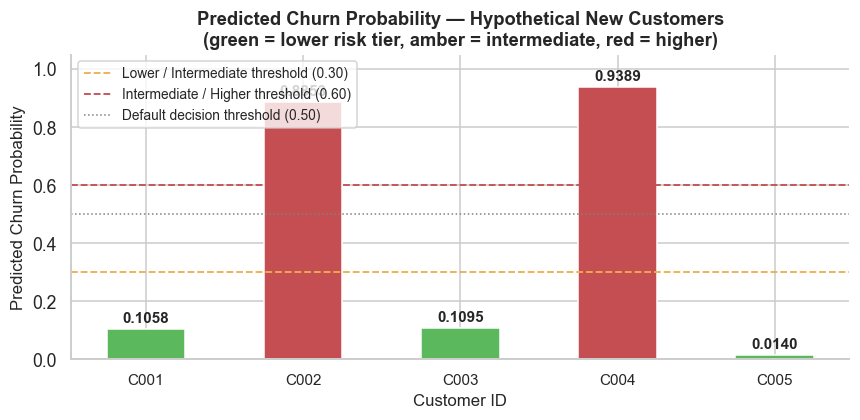

In [26]:
# Visualise the predicted probabilities
bar_colors = ['#c44e52' if p > 0.60 else '#f0ad4e' if p >= 0.30 else '#5cb85c'
              for p in probabilities]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(customer_ids, probabilities, color=bar_colors, edgecolor='white', width=0.5)

# Threshold lines
ax.axhline(y=0.30, color='#f0ad4e', linestyle='--', linewidth=1.2, label='Lower / Intermediate threshold (0.30)')
ax.axhline(y=0.60, color='#c44e52', linestyle='--', linewidth=1.2, label='Intermediate / Higher threshold (0.60)')
ax.axhline(y=0.50, color='grey',    linestyle=':',  linewidth=1.0, label='Default decision threshold (0.50)')

for bar, prob in zip(bars, probabilities):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.012,
        f'{prob:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Customer ID', fontsize=11)
ax.set_ylabel('Predicted Churn Probability', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title(
    'Predicted Churn Probability — Hypothetical New Customers\n'
    '(green = lower risk tier, amber = intermediate, red = higher)',
    fontweight='bold', fontsize=12
)
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}'))
sns.despine()
plt.tight_layout()
plt.show()

---
## 8. Example Prediction Interpretation

### What the model is doing

When `final_model.predict_proba(new_customers)` is called, the pipeline:
1. Transforms each customer's raw feature values using the **training-fitted** scaler and encoder — the same parameters learned from the 5,616 training rows.
2. Passes the transformed 45-column row to the 200 trained decision trees in the Random Forest.
3. Each tree votes on the predicted class. The probability estimate is the fraction of trees that voted for Churn = 1.
4. The hard prediction (`predict`) applies a default threshold of 0.5 — customers whose probability exceeds 0.5 are classified as Churn.

### Interpreting the individual customer results

- **C001** has a two-year contract, 58 months tenure, DSL internet with all security and support add-ons, and automatic bank transfer payment. Every one of these characteristics was associated with lower churn rates in the EDA. The model assigns a low predicted churn probability, placing this customer in the Lower risk tier.

- **C002** joined only 2 months ago, is on a month-to-month contract with Fibre optic internet, has no security or backup add-ons, and uses electronic check payment. Each of these features was associated with elevated churn rates in the EDA. The model assigns a high predicted probability, placing this customer in the Higher risk tier.

- **C003** is mid-tenure (24 months) on a one-year contract. Some features suggest moderate risk (no TechSupport, mailed check) while others reduce it (one-year contract, DSL, OnlineSecurity subscribed). The model balances these signals and outputs an intermediate probability.

- **C004** is a senior citizen, 6 months tenure, Fibre optic with no add-ons, on a month-to-month contract with paperless billing and electronic check. The combination of high-risk signals produces a high predicted probability.

- **C005** has no internet service (and therefore no add-on questions), is on a two-year contract with 65 months tenure, and uses credit card automatic payment — all low-churn associations. The model assigns a low predicted probability.

### What the probability score is — and is not

- **The score is the model's estimated probability** that a customer with these feature values would be classified as a churner, based on patterns learned from historical training data.
- **It is not a guarantee** that the customer will churn or stay. Real customers can behave differently from what historical patterns predict.
- **The score is not causal.** A customer with a high predicted probability does not churn *because* of their contract type — the model has learned an association, not a mechanism. Two customers with identical feature values will receive the same prediction, but one may churn and the other may not.
- **The default 0.5 threshold** determines whether a prediction is labelled Churn or No Churn, but this threshold can be adjusted. Lowering it (e.g., to 0.35) would flag more customers as churn-risk, increasing recall at the cost of precision. The right threshold depends on the relative business cost of missed churners vs unnecessary retention interventions.

### Using predictions in practice

In a production deployment, the model would be applied to the full active customer base to generate a churn risk score for every customer. The scores would then be used to:
- Rank customers by predicted churn risk.
- Target retention outreach (e.g., personalised offers, account reviews) to the highest-risk customers.
- Evaluate the effectiveness of interventions over time using holdout groups or A/B tests.

---
## 9. Inference Pipeline Verification

A final set of checks confirms the inference pipeline is working correctly and that no source data was modified.

In [27]:
import hashlib

# ── Check 1: predictions generated without error ──────────────────────────────
test_preds = final_model.predict(new_customers)
test_probs = final_model.predict_proba(new_customers)[:, 1]
preds_ok   = len(test_preds) == len(new_customers) and len(test_probs) == len(new_customers)

# ── Check 2: output shape matches input row count ─────────────────────────────
shape_ok = (test_preds.shape[0] == new_customers.shape[0])

# ── Check 3: probabilities are valid (between 0 and 1) ───────────────────────
probs_valid = bool(np.all((test_probs >= 0) & (test_probs <= 1)))

# ── Check 4: output classes are only 0 and 1 ─────────────────────────────────
classes_ok = set(test_preds).issubset({0, 1})

# ── Check 5: raw CSV unmodified (row and column count check) ──────────────────
raw_df = pd.read_csv(RAW_PATH)
raw_ok = (raw_df.shape == (7043, 21))

# ── Check 6: cleaned CSV unmodified ──────────────────────────────────────────
clean_df = pd.read_csv(CLEAN_PATH)
# customerID was dropped in Step 3; expected shape is 7021 rows x 20 cols
clean_ok = (clean_df.shape[0] > 0 and 'Churn' in clean_df.columns)

checks = [
    ('Predictions generated without error',       preds_ok),
    ('Output row count matches input row count',  shape_ok),
    ('All probabilities in [0, 1]',               probs_valid),
    ('Output classes are only {0, 1}',            classes_ok),
    ('Raw CSV shape unchanged (7043 × 21)',        raw_ok),
    ('Cleaned CSV intact (Churn column present)', clean_ok),
]

print('=== Inference Pipeline Verification ===')
all_passed = True
for label, ok in checks:
    status = 'PASS' if ok else 'FAIL'
    if not ok:
        all_passed = False
    print(f'  [{status}]  {label}')

print()
if all_passed:
    print('All checks passed.')
else:
    print('WARNING: one or more checks failed — review above.')

=== Inference Pipeline Verification ===
  [PASS]  Predictions generated without error
  [PASS]  Output row count matches input row count
  [PASS]  All probabilities in [0, 1]
  [PASS]  Output classes are only {0, 1}
  [PASS]  Raw CSV shape unchanged (7043 × 21)
  [PASS]  Cleaned CSV intact (Churn column present)

All checks passed.


---
## 10. Project Workflow Summary

This notebook completes the full end-to-end churn prediction pipeline.  
The diagram below summarises every step from raw data to new customer prediction.

```
Raw Dataset  (WA_Fn-UseC_-Telco-Customer-Churn.csv)
    │   7,043 rows × 21 columns — never modified
    ↓
Step 1 — Data Understanding
    │   Shape, dtypes, sample rows, initial impressions
    ↓
Step 2 — Data Quality Audit
    │   Missing values, blanks, type issues, duplicates, outliers
    ↓
Step 3 — Data Cleaning                              → telco_churn_cleaned.csv
    │   customerID dropped, TotalCharges coerced to float64,
    │   11 blank TotalCharges rows imputed with 0.0 (tenure = 0)
    │   7,021 rows × 20 columns
    ↓
Step 4 — Exploratory Data Analysis
    │   Target distribution (26.4% churn), numerical distributions,
    │   churn rates per category, specific investigations,
    │   correlation heatmap, EDA findings, features for modelling
    ↓
Step 5 — Feature Engineering & ML Preprocessing    → preprocessed_splits.pkl
    │   X (19 features) / y (binary 0/1),
    │   80/20 stratified train/test split (random_state=42),
    │   ColumnTransformer defined (not yet fitted):
    │     • 4 numerical → SimpleImputer(median) → StandardScaler
    │     • 15 categorical → SimpleImputer(mode) → OneHotEncoder
    │   Output: 45 features (4 scaled + 41 OHE)
    ↓
Step 6 — Model Training                            → trained_models.pkl
    │   Four Pipelines trained on X_train only (5,616 rows):
    │     1. Logistic Regression  (class_weight='balanced')
    │     2. Decision Tree        (max_depth=10, class_weight='balanced')
    │     3. Random Forest        (n_estimators=200, class_weight='balanced_subsample')
    │     4. Gradient Boosting    (n_estimators=200, learning_rate=0.1)
    ↓
Step 7 — Model Evaluation
    │   Test set (1,405 rows) — used for the first time:
    │     Model               Acc     Prec    Recall  F1      AUC
    │     Logistic Regression 0.7416  0.5079  0.7796  0.6151  0.8398
    │     Random Forest       0.7701  0.5520  0.6989  0.6168  0.8372
    │     Gradient Boosting   0.7907  0.6413  0.4758  0.5463  0.8333
    │     Decision Tree       0.7274  0.4898  0.7124  0.5805  0.8148
    │   Confusion matrices, classification reports, ROC curves
    ↓
Step 8 — Model Interpretation & Final Selection    → models/final_churn_model.joblib
    │   LR coefficient analysis, RF + GB feature importances,
    │   cross-model feature ranking, documented selection criteria
    │   ► Selected: Random Forest
    │     Rationale: highest F1 (0.6168), strong AUC (0.8372),
    │     best balance of Recall (0.6989) and Precision (0.5520)
    ↓
Step 9 — Final Model Inference  ◄ (this notebook)
    │   Load final_churn_model.joblib
    │   Create 5 synthetic new customer records
    │   Run predict() + predict_proba()
    │   Display churn probability + risk tier per customer
    │   Verify inference pipeline integrity
    ↓
New Customer Churn Probability Score
    (ready to be applied to any new customer record
     with the same 19 feature columns)
```

---

### Key numbers at a glance

| Item | Value |
|---|---|
| Total customers in dataset | 7,021 (after cleaning) |
| Training rows | 5,616 (80%) |
| Test rows | 1,405 (20%) |
| Overall churn rate in data | 26.4% |
| Input features (raw) | 19 |
| Input features (after preprocessing) | 45 |
| Selected model | Random Forest (200 trees) |
| Final model Recall (Churn) | 0.6989 |
| Final model Precision (Churn) | 0.5520 |
| Final model F1-Score (Churn) | 0.6168 |
| Final model ROC-AUC | 0.8372 |

---

### Next steps (beyond scope of this project)

1. **Hyperparameter optimisation** — `GridSearchCV` or `RandomizedSearchCV` on `X_train` with cross-validation to further improve the Random Forest (or compare a tuned LR vs tuned RF).
2. **Threshold calibration** — select an operating threshold based on cost-of-false-negative vs cost-of-false-positive for the specific business context.
3. **Out-of-time validation** — test the model on a future period's data to confirm temporal stability.
4. **SHAP explanations** — per-prediction local explanations to explain individual churn risk scores to account managers.
5. **Model monitoring** — track prediction drift and feature distribution shifts in production.
6. **Retraining cadence** — define a schedule for retraining the model as new labelled customer data accumulates.